<a href="https://colab.research.google.com/github/ddopazo92/Introduccion_datascience_diego_dopazo/blob/ciencia-de-datos-II/PROYECTO_DOPAZODIEGO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PROYECTO FINAL — Predicción Mundial de Fútbol 2026
### Análisis Predictivo con Machine Learning
**Autor:** Diego Dopazo | **Curso:** Ciencia de Datos II

---
## 1. ABSTRACTO

### Motivación
El Mundial de Fútbol 2026 es el primer torneo con **48 selecciones**. Este proyecto predice qué equipos clasificarán a octavos de final usando datos reales de resultados internacionales obtenidos de Kaggle (dataset `martj42/international_results`, +49.000 partidos desde 1872 hasta 2026) combinados con el ranking FIFA de cada selección.

La unidad de análisis es **cada partido individual** disputado por las 48 selecciones clasificadas entre 2022 y 2025. Para cada partido se construyen features que reflejan el estado acumulado de la selección hasta ese momento: victorias, goles, rendimiento reciente, ranking FIFA, tipo de torneo, condición de local/visitante y estadísticas del rival. Esto genera un dataset de **miles de observaciones**, superando la limitación de trabajar con una sola fila por selección.

### Problema central
**Clasificación binaria:** dado el perfil de rendimiento de una selección en un partido específico (sus estadísticas acumuladas hasta ese momento), ¿esa selección clasificará a octavos de final del Mundial 2026?

### Fuente de datos
- **Kaggle:** `martj42/international_results` — resultados internacionales desde 1872 hasta 2026
- **Ranking FIFA:** asignado manualmente según actualización de marzo 2026

### Audiencia
- Aficionados al fútbol interesados en análisis de datos
- Analistas deportivos y periodistas especializados
- Estudiantes y practicantes de ciencia de datos

### Estructura del cuaderno
1. Importaciones y configuración
2. Carga y filtrado del dataset
3. Construcción del dataset partido a partido
4. Análisis Exploratorio de Datos (EDA)
5. Ingeniería de atributos y preparación para ML
6. Entrenamiento y comparación de modelos
7. Optimización de hiperparámetros
8. Evaluación y selección del mejor modelo
9. Interpretabilidad con SHAP
10. Conclusiones

---
## 2. PREGUNTAS Y PROBLEMA A RESOLVER

### Problema principal — Clasificación Binaria

> **¿Qué selecciones clasificarán a los octavos de final del Mundial 2026, basándonos en su rendimiento partido a partido entre 2022 y 2025?**

La problemática se modela como un **problema de clasificación binaria supervisada**:
cada fila del dataset representa un partido de una selección. Los features describen el estado acumulado de esa selección hasta ese partido. El target indica si esa selección terminó clasificando (1) o no (0) a octavos del Mundial 2026.

### Preguntas secundarias

1. ¿El ranking FIFA es el predictor más importante de clasificación a octavos?
2. ¿Las selecciones anfitrionas (México, EE.UU., Canadá) muestran mejor rendimiento acumulado?
3. ¿Jugar de local vs. visitante afecta el rendimiento acumulado de una selección?
4. ¿Qué tipo de torneo (eliminatoria, copa continental, amistoso) aporta más señal predictiva?
5. ¿Qué variables son más determinantes según SHAP?

### Variable objetivo

| Valor | Significado |
|---|---|
| **1** | La selección clasifica a octavos de final del Mundial 2026 |
| **0** | La selección no avanza a octavos |

> **Nota:** el target es fijo por selección (no varía por partido). Lo que varía entre filas son los features acumulados hasta cada partido.

---
## 3. IMPORTACIONES Y CONFIGURACIÓN

In [1]:
!pip install xgboost shap --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import (train_test_split, cross_val_score,
                                     StratifiedKFold, GridSearchCV, learning_curve)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix, roc_curve)
from xgboost import XGBClassifier
import shap

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("tab10")
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:.3f}".format)

print("✓ Librerías importadas correctamente")

✓ Librerías importadas correctamente


---
## 4. CARGA Y FILTRADO DEL DATASET

Se carga el dataset `martj42/international_results` directamente desde GitHub y se filtra
para conservar únicamente los partidos (2022–2025) donde al menos uno de los equipos
pertenece a las **48 selecciones clasificadas al Mundial 2026**.

In [2]:
# ── Lista oficial de clasificados al Mundial 2026 ──────────────────────────
CLASIFICADOS_2026 = [
    # CONCACAF (8)
    "United States","Mexico","Canada","Haiti","Panama","Curacao","Jamaica","Suriname",
    # CONMEBOL (6)
    "Argentina","Brazil","Ecuador","Uruguay","Paraguay","Colombia",
    # UEFA (16)
    "England","France","Croatia","Norway","Portugal","Germany","Netherlands","Spain",
    "Scotland","Belgium","Austria","Switzerland","Sweden","Turkey",
    "Czech Republic","Bosnia and Herzegovina",
    # AFC (9)
    "Japan","Iran","Jordan","Uzbekistan","South Korea",
    "Australia","Qatar","Saudi Arabia","Iraq",
    # CAF (10)
    "Morocco","Tunisia","Algeria","Egypt","Ghana","Cape Verde",
    "Senegal","Ivory Coast","South Africa","DR Congo",
    # OFC (1)
    "New Zealand",
]

# ── Ranking FIFA (marzo 2026) ───────────────────────────────────────────────
RANKING_FIFA = {
    "Argentina":1,"France":2,"England":3,"Belgium":4,"Brazil":5,
    "Portugal":6,"Netherlands":7,"Spain":8,"Germany":9,"Croatia":10,
    "Uruguay":11,"Colombia":12,"Morocco":13,"Japan":14,"United States":15,
    "Mexico":16,"Canada":17,"Senegal":18,"Switzerland":19,"Ecuador":20,
    "South Korea":21,"Austria":22,"Australia":23,"Norway":24,"Turkey":25,
    "Iran":26,"Sweden":27,"Czech Republic":28,"Scotland":29,"Algeria":30,
    "Egypt":31,"Ivory Coast":32,"Bosnia and Herzegovina":34,"Paraguay":35,
    "Ghana":36,"Saudi Arabia":37,"Qatar":38,"Uzbekistan":39,"Jordan":40,
    "Iraq":41,"Tunisia":42,"South Africa":43,"Suriname":44,"Jamaica":45,
    "Curacao":46,"New Zealand":47,"Haiti":48,"Cape Verde":49,"DR Congo":50,"Panama":51,
}

# ── Confederación por selección ────────────────────────────────────────────
CONF_MAP = {
    "United States":"CONCACAF","Mexico":"CONCACAF","Canada":"CONCACAF",
    "Haiti":"CONCACAF","Panama":"CONCACAF","Curacao":"CONCACAF",
    "Jamaica":"CONCACAF","Suriname":"CONCACAF",
    "Argentina":"CONMEBOL","Brazil":"CONMEBOL","Ecuador":"CONMEBOL",
    "Uruguay":"CONMEBOL","Paraguay":"CONMEBOL","Colombia":"CONMEBOL",
    "England":"UEFA","France":"UEFA","Croatia":"UEFA","Norway":"UEFA",
    "Portugal":"UEFA","Germany":"UEFA","Netherlands":"UEFA","Spain":"UEFA",
    "Scotland":"UEFA","Belgium":"UEFA","Austria":"UEFA","Switzerland":"UEFA",
    "Sweden":"UEFA","Turkey":"UEFA","Czech Republic":"UEFA",
    "Bosnia and Herzegovina":"UEFA",
    "Japan":"AFC","Iran":"AFC","Jordan":"AFC","Uzbekistan":"AFC",
    "South Korea":"AFC","Australia":"AFC","Qatar":"AFC",
    "Saudi Arabia":"AFC","Iraq":"AFC",
    "Morocco":"CAF","Tunisia":"CAF","Algeria":"CAF","Egypt":"CAF",
    "Ghana":"CAF","Cape Verde":"CAF","Senegal":"CAF","Ivory Coast":"CAF",
    "South Africa":"CAF","DR Congo":"CAF",
    "New Zealand":"OFC",
}

ANFITRIONES = {"Mexico","United States","Canada"}

# ── Target: selecciones que clasifican a octavos (top-16 FIFA + anfitriones) ─
CLASIFICA_OCTAVOS = set(
    [s for s, r in RANKING_FIFA.items() if r <= 16] + list(ANFITRIONES)
)

# ── Carga del dataset ───────────────────────────────────────────────────────
URL = "https://raw.githubusercontent.com/martj42/international_results/master/results.csv"
print("Descargando dataset...")
df_raw = pd.read_csv(URL)
df_raw["date"] = pd.to_datetime(df_raw["date"])
df_raw["year"] = df_raw["date"].dt.year

# Filtrar 2022-2025
df_raw = df_raw[(df_raw["year"] >= 2022) & (df_raw["year"] <= 2025)].copy()

# Conservar solo partidos donde al menos un equipo es clasificado
mask = (df_raw["home_team"].isin(CLASIFICADOS_2026)) | (df_raw["away_team"].isin(CLASIFICADOS_2026))
df_raw = df_raw[mask].reset_index(drop=True)

print(f"✓ Partidos cargados (2022-2025, con al menos un clasificado): {len(df_raw):,}")
print(f"  Rango: {df_raw['date'].min().date()} → {df_raw['date'].max().date()}")
print(f"  Torneos distintos: {df_raw['tournament'].nunique()}")
print(f"\nTipos de torneo más frecuentes:")
print(df_raw["tournament"].value_counts().head(8).to_string())

Descargando dataset...
✓ Partidos cargados (2022-2025, con al menos un clasificado): 1,944
  Rango: 2022-01-05 → 2025-12-31
  Torneos distintos: 32

Tipos de torneo más frecuentes:
tournament
FIFA World Cup qualification            534
Friendly                                491
UEFA Nations League                     174
African Cup of Nations qualification    112
UEFA Euro qualification                 109
African Cup of Nations                   90
CONCACAF Nations League                  79
FIFA World Cup                           63


---
## 5. CONSTRUCCIÓN DEL DATASET PARTIDO A PARTIDO

Para cada partido del dataset se generan **dos filas**: una para el equipo local y otra para
el visitante (siempre que pertenezcan a los clasificados). Cada fila contiene:

- **Features del equipo:** estadísticas acumuladas hasta ese partido (victorias, goles, efectividad, etc.)
- **Ranking FIFA** del equipo
- **Tipo de torneo** (codificado)
- **Condición** de local o visitante
- **Features del rival:** ranking FIFA y estadísticas acumuladas del oponente

El target `clasifica_octavos` es fijo por selección: vale **1** si la selección terminó
clasificando a octavos del Mundial 2026, y **0** en caso contrario.

> Este enfoque transforma el problema de 48 filas (una por selección) a **miles de filas**
> (una por partido-selección), dando a los modelos suficiente señal estadística.

In [3]:
# ── Categorizar tipo de torneo ──────────────────────────────────────────────
def categorizar_torneo(nombre):
    n = nombre.lower()
    if "world cup" in n and "qualif" not in n:
        return "Copa_del_Mundo"
    elif "qualif" in n or "qualification" in n:
        return "Eliminatoria"
    elif any(x in n for x in ["copa america","euro","gold cup","africa cup","asian cup",
                               "nations league","confederation"]):
        return "Copa_Continental"
    elif "friendly" in n or "amistoso" in n:
        return "Amistoso"
    else:
        return "Otro"

df_raw["cat_torneo"] = df_raw["tournament"].apply(categorizar_torneo)

# ── Construir estadísticas acumuladas por selección ──────────────────────────
# Para cada partido se calculan las stats ANTERIORES a ese partido (expanding)
# Primero expandimos a formato largo: una fila por (partido, equipo)

registros = []

for equipo in CLASIFICADOS_2026:
    # Partidos como local
    local = df_raw[df_raw["home_team"] == equipo][
        ["date","home_team","away_team","home_score","away_score","cat_torneo"]
    ].copy()
    local.columns = ["date","equipo","rival","goles_favor","goles_contra","cat_torneo"]
    local["es_local"] = 1

    # Partidos como visitante
    visit = df_raw[df_raw["away_team"] == equipo][
        ["date","away_team","home_team","away_score","home_score","cat_torneo"]
    ].copy()
    visit.columns = ["date","equipo","rival","goles_favor","goles_contra","cat_torneo"]
    visit["es_local"] = 0

    partidos = pd.concat([local, visit]).sort_values("date").reset_index(drop=True)

    if len(partidos) == 0:
        continue

    partidos["victoria"]  = (partidos["goles_favor"] > partidos["goles_contra"]).astype(int)
    partidos["empate"]    = (partidos["goles_favor"] == partidos["goles_contra"]).astype(int)
    partidos["derrota"]   = (partidos["goles_favor"] < partidos["goles_contra"]).astype(int)
    partidos["dif_goles"] = partidos["goles_favor"] - partidos["goles_contra"]

    # Stats acumuladas HASTA el partido (shift para no incluir el partido actual)
    for col in ["victoria","empate","derrota","goles_favor","goles_contra","dif_goles"]:
        partidos[f"acum_{col}"] = partidos[col].shift(1).expanding().sum().fillna(0)

    partidos["acum_pj"]           = np.arange(len(partidos))  # partidos jugados antes
    partidos["acum_efectividad"]  = np.where(
        partidos["acum_pj"] > 0,
        partidos["acum_victoria"] / partidos["acum_pj"], 0
    )
    partidos["acum_ratio_goles"]  = np.where(
        partidos["acum_goles_contra"] > 0,
        partidos["acum_goles_favor"] / partidos["acum_goles_contra"], 0
    )
    partidos["acum_goles_x_pj"]   = np.where(
        partidos["acum_pj"] > 0,
        partidos["acum_goles_favor"] / partidos["acum_pj"], 0
    )

    # Metadatos del equipo
    partidos["ranking_fifa"]      = RANKING_FIFA.get(equipo, 99)
    partidos["es_anfitrion"]      = int(equipo in ANFITRIONES)
    partidos["confederacion"]     = CONF_MAP.get(equipo, "OTROS")
    partidos["clasifica_octavos"] = int(equipo in CLASIFICA_OCTAVOS)

    registros.append(partidos)

df_largo = pd.concat(registros, ignore_index=True)

print(f"✓ Dataset partido a partido construido")
print(f"  Filas totales : {len(df_largo):,}")
print(f"  Selecciones   : {df_largo['equipo'].nunique()}")
print(f"  Columnas      : {len(df_largo.columns)}")
print(f"\nDistribución del target:")
vc = df_largo["clasifica_octavos"].value_counts()
print(f"  Clasifica a octavos (1) : {vc.get(1,0):,} filas ({vc.get(1,0)/len(df_largo)*100:.1f}%)")
print(f"  No clasifica       (0) : {vc.get(0,0):,} filas ({vc.get(0,0)/len(df_largo)*100:.1f}%)")

✓ Dataset partido a partido construido
  Filas totales : 2,467
  Selecciones   : 49
  Columnas      : 25

Distribución del target:
  Clasifica a octavos (1) : 890 filas (36.1%)
  No clasifica       (0) : 1,577 filas (63.9%)


In [4]:
# ── Agregar features del rival ──────────────────────────────────────────────
# Para cada partido tomamos el ranking FIFA y stats acumuladas del rival
# Construimos un resumen por (rival, fecha): sus stats acumuladas en esa fecha

# Stats acumuladas del rival al momento del partido
rival_stats = df_largo[["equipo","date","acum_pj","acum_victoria","acum_efectividad",
                          "acum_goles_favor","acum_ratio_goles","ranking_fifa"]].copy()
rival_stats.columns = ["rival","date","rival_acum_pj","rival_acum_v","rival_efectividad",
                        "rival_acum_gf","rival_ratio_goles","rival_ranking_fifa"]

# Merge: para cada fila de df_largo, traer stats del rival en esa misma fecha
df_largo = df_largo.merge(rival_stats, on=["rival","date"], how="left")

# Rellenar rivales que no están en los 48 clasificados
df_largo["rival_ranking_fifa"]  = df_largo["rival_ranking_fifa"].fillna(99)
df_largo["rival_acum_pj"]       = df_largo["rival_acum_pj"].fillna(0)
df_largo["rival_acum_v"]        = df_largo["rival_acum_v"].fillna(0)
df_largo["rival_efectividad"]   = df_largo["rival_efectividad"].fillna(0)
df_largo["rival_acum_gf"]       = df_largo["rival_acum_gf"].fillna(0)
df_largo["rival_ratio_goles"]   = df_largo["rival_ratio_goles"].fillna(0)

# Diferencia de ranking (negativo = equipo mejor rankeado)
df_largo["dif_ranking"]         = df_largo["ranking_fifa"] - df_largo["rival_ranking_fifa"]

# Codificar torneo como numérico ordinal (peso competitivo)
peso_torneo = {
    "Copa_del_Mundo": 4, "Eliminatoria": 3,
    "Copa_Continental": 2, "Amistoso": 1, "Otro": 1
}
df_largo["peso_torneo"] = df_largo["cat_torneo"].map(peso_torneo)

print(f"✓ Features del rival agregadas")
print(f"  Filas finales : {len(df_largo):,}")
print(f"  Nulos residuales: {df_largo.isnull().sum().sum()}")
print()
print("Vista de las primeras filas:")
cols_vista = ["equipo","date","rival","es_local","cat_torneo","ranking_fifa",
              "rival_ranking_fifa","acum_pj","acum_victoria","acum_efectividad",
              "clasifica_octavos"]
print(df_largo[cols_vista].head(8).to_string(index=False))

✓ Features del rival agregadas
  Filas finales : 2,467
  Nulos residuales: 0

Vista de las primeras filas:
       equipo       date       rival  es_local   cat_torneo  ranking_fifa  rival_ranking_fifa  acum_pj  acum_victoria  acum_efectividad  clasifica_octavos
United States 2022-01-27 El Salvador         1 Eliminatoria            15              99.000        0          0.000             0.000                  1
United States 2022-01-30      Canada         0 Eliminatoria            15              17.000        1          1.000             1.000                  1
United States 2022-02-02    Honduras         1 Eliminatoria            15              99.000        2          1.000             0.500                  1
United States 2022-03-24      Mexico         0 Eliminatoria            15              16.000        3          2.000             0.667                  1
United States 2022-03-27      Panama         1 Eliminatoria            15              51.000        4          2.000 

---
## 6. ANÁLISIS EXPLORATORIO DE DATOS (EDA)

Análisis descriptivo del dataset partido a partido: distribuciones, valores faltantes,
comparativas por target y por confederación.

### 6.1 Análisis de Valores Faltantes

Valores faltantes por columna:
  ✓ Ninguno — dataset completamente limpio


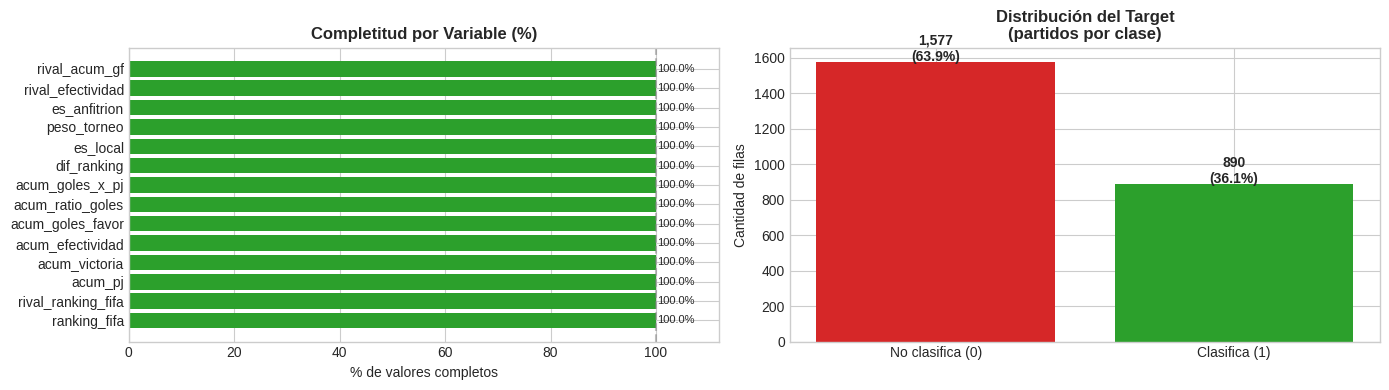


Estadísticas descriptivas del dataset:
       ranking_fifa  acum_pj  acum_victoria  acum_efectividad  dif_ranking  \
count      2467.000 2467.000       2467.000          2467.000     2467.000   
mean         25.330   25.293         12.998             0.501      -41.173   
std          14.677   15.602          8.824             0.185       38.776   
min           1.000    0.000          0.000             0.000      -98.000   
25%          13.000   12.000          6.000             0.405      -74.000   
50%          25.000   25.000         12.000             0.500      -54.000   
75%          38.000   37.000         19.000             0.600       -3.000   
max          51.000   68.000         43.000             1.000       50.000   

       peso_torneo  
count     2467.000  
mean         2.052  
std          0.961  
min          1.000  
25%          1.000  
50%          2.000  
75%          3.000  
max          4.000  


In [5]:
# ── Completitud del dataset ─────────────────────────────────────────────────
cols_ml = ["ranking_fifa","rival_ranking_fifa","acum_pj","acum_victoria","acum_efectividad",
           "acum_goles_favor","acum_ratio_goles","acum_goles_x_pj","dif_ranking",
           "es_local","peso_torneo","es_anfitrion","rival_efectividad","rival_acum_gf"]

nulos = df_largo[cols_ml].isnull().sum()
print("Valores faltantes por columna:")
print(nulos[nulos > 0] if nulos.sum() > 0 else "  ✓ Ninguno — dataset completamente limpio")

# Heatmap de completitud
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

completitud = (df_largo[cols_ml].notnull().sum() / len(df_largo) * 100).sort_values()
colores = ["#d62728" if v < 100 else "#2ca02c" for v in completitud.values]
axes[0].barh(completitud.index, completitud.values, color=colores)
axes[0].axvline(x=100, color="gray", linestyle="--", alpha=0.5)
axes[0].set_title("Completitud por Variable (%)", fontweight="bold")
axes[0].set_xlabel("% de valores completos")
axes[0].set_xlim(0, 112)
for i, v in enumerate(completitud.values):
    axes[0].text(v + 0.3, i, f"{v:.1f}%", va="center", fontsize=8)

# Distribución del target
vc = df_largo["clasifica_octavos"].value_counts()
axes[1].bar(["No clasifica (0)","Clasifica (1)"], [vc.get(0,0), vc.get(1,0)],
            color=["#d62728","#2ca02c"])
axes[1].set_title("Distribución del Target\n(partidos por clase)", fontweight="bold")
axes[1].set_ylabel("Cantidad de filas")
for i, v in enumerate([vc.get(0,0), vc.get(1,0)]):
    axes[1].text(i, v + 5, f"{v:,}\n({v/len(df_largo)*100:.1f}%)", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

print(f"\nEstadísticas descriptivas del dataset:")
print(df_largo[["ranking_fifa","acum_pj","acum_victoria","acum_efectividad",
                "dif_ranking","peso_torneo"]].describe().round(3))

### 6.2 Distribución de Features Clave por Target

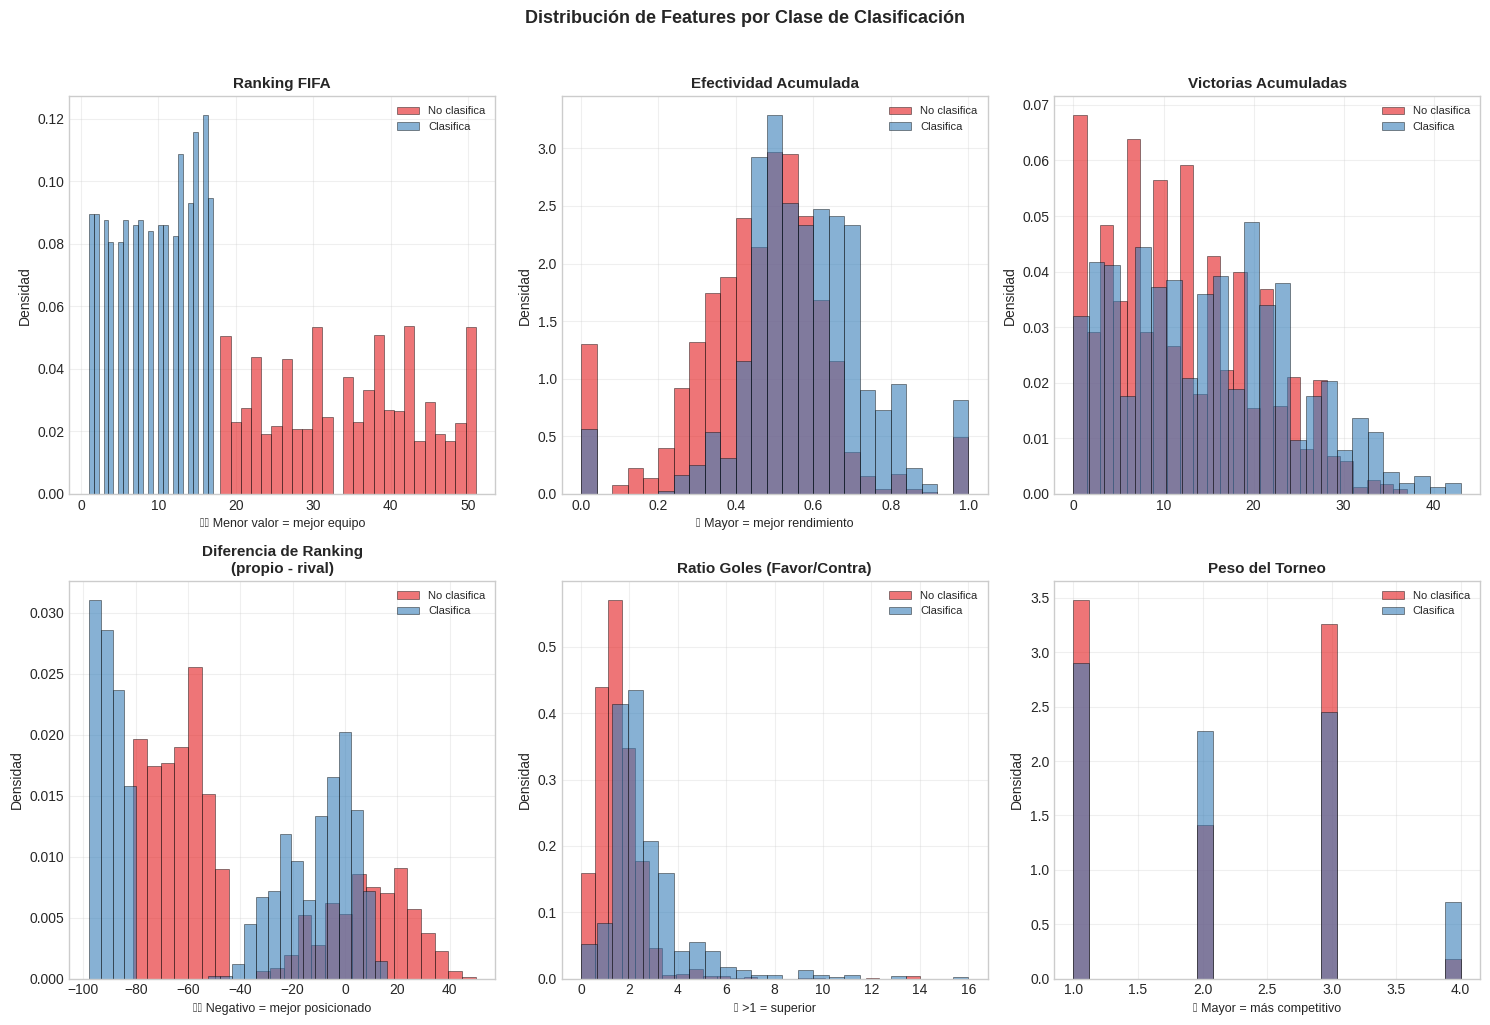

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

features_plot = [
    ("ranking_fifa", "Ranking FIFA", "⚠️ Menor valor = mejor equipo"),
    ("acum_efectividad", "Efectividad Acumulada", "✅ Mayor = mejor rendimiento"),
    ("acum_victoria", "Victorias Acumuladas", ""),
    ("dif_ranking", "Diferencia de Ranking\n(propio - rival)", "⚠️ Negativo = mejor posicionado"),
    ("acum_ratio_goles", "Ratio Goles (Favor/Contra)", "✅ >1 = superior"),
    ("peso_torneo", "Peso del Torneo", "✅ Mayor = más competitivo"),
]

for ax, (col, title, note) in zip(axes, features_plot):
    for target, color, label in [(0, "#e41a1c", "No clasifica"), (1, "#377eb8", "Clasifica")]:
        datos = df_largo[df_largo["clasifica_octavos"]==target][col].dropna()
        ax.hist(datos, bins=25, alpha=0.6, color=color, label=label, density=True, edgecolor='black', linewidth=0.5)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel(note, fontsize=9)
    ax.set_ylabel("Densidad")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("Distribución de Features por Clase de Clasificación", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 6.3 Condición de Juego y Tipo de Torneo

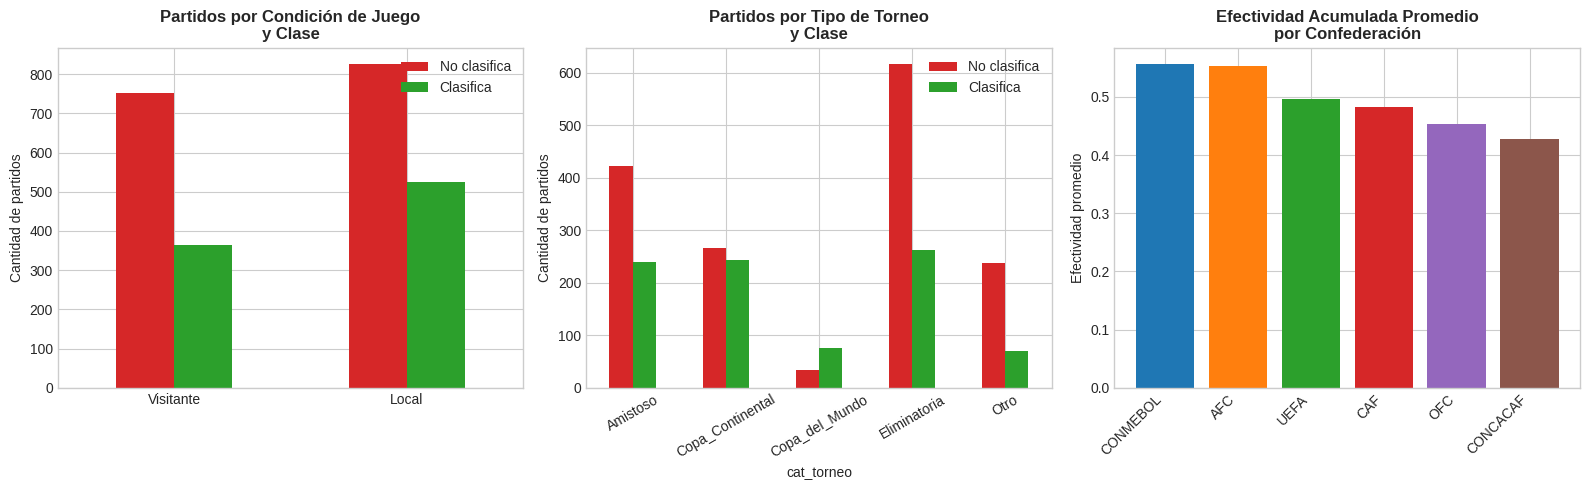

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Local vs visitante por target
loc_data = df_largo.groupby(["es_local","clasifica_octavos"]).size().unstack(fill_value=0)
loc_data.index = ["Visitante","Local"]
loc_data.columns = ["No clasifica","Clasifica"]
loc_data.plot(kind="bar", ax=axes[0], color=["#d62728","#2ca02c"], rot=0)
axes[0].set_title("Partidos por Condición de Juego\ny Clase", fontweight="bold")
axes[0].set_ylabel("Cantidad de partidos")
axes[0].legend()

# Tipo de torneo por target
tor_data = df_largo.groupby(["cat_torneo","clasifica_octavos"]).size().unstack(fill_value=0)
tor_data.columns = ["No clasifica","Clasifica"]
tor_data.plot(kind="bar", ax=axes[1], color=["#d62728","#2ca02c"], rot=30)
axes[1].set_title("Partidos por Tipo de Torneo\ny Clase", fontweight="bold")
axes[1].set_ylabel("Cantidad de partidos")
axes[1].legend()

# Efectividad acumulada por confederación
conf_ef = df_largo.groupby("confederacion")["acum_efectividad"].mean().sort_values(ascending=False)
axes[2].bar(conf_ef.index, conf_ef.values, color=sns.color_palette("tab10", len(conf_ef)))
axes[2].set_title("Efectividad Acumulada Promedio\npor Confederación", fontweight="bold")
axes[2].set_xticklabels(conf_ef.index, rotation=45, ha="right")
axes[2].set_ylabel("Efectividad promedio")

plt.tight_layout()
plt.show()

### 6.4 Matriz de Correlación

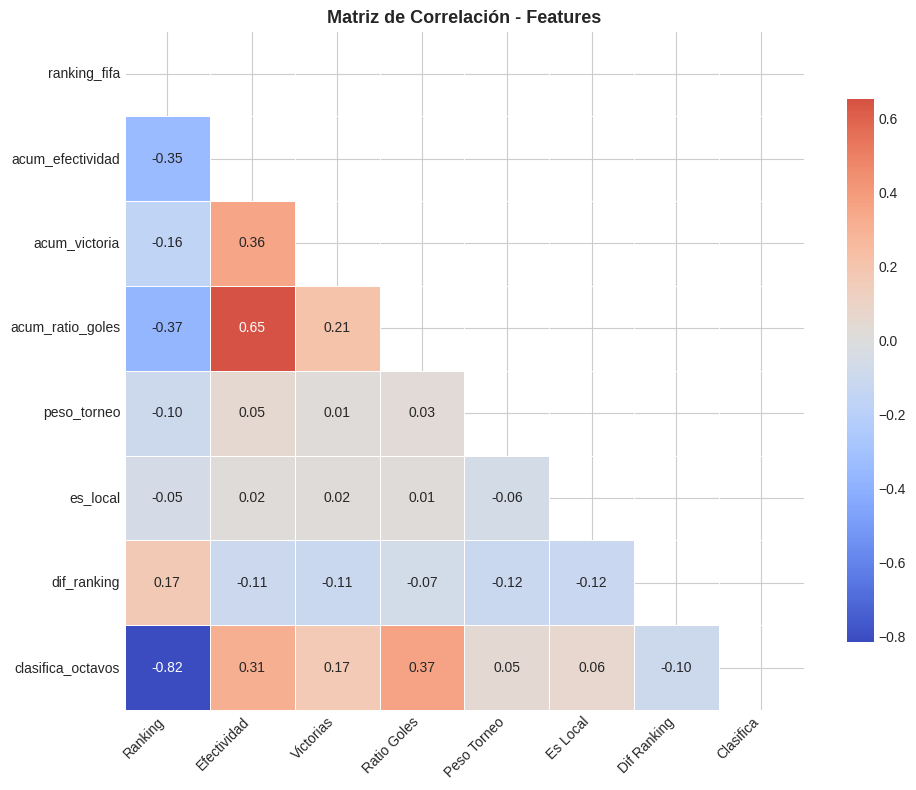


Correlación con el target (clasifica a octavos):
  ranking_fifa        : -0.817  ████████████████████████
  acum_ratio_goles    : +0.365  ██████████
  acum_efectividad    : +0.314  █████████
  acum_victoria       : +0.168  █████
  dif_ranking         : -0.100  ██
  es_local            : +0.064  █
  peso_torneo         : +0.049  █


In [19]:
cols_corr = ["ranking_fifa", "acum_efectividad", "acum_victoria",
             "acum_ratio_goles", "peso_torneo", "es_local",
             "dif_ranking", "clasifica_octavos"]

corr_matrix = df_largo[cols_corr].corr()
corr_matrix.columns = ["Ranking", "Efectividad", "Victorias", "Ratio Goles",
                        "Peso Torneo", "Es Local", "Dif Ranking", "Clasifica"]

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink":0.8})
plt.title("Matriz de Correlación - Features", fontsize=13, fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Correlación con target
corr_target = df_largo[cols_corr].corr()["clasifica_octavos"].drop("clasifica_octavos").sort_values(key=abs, ascending=False)
print("\nCorrelación con el target (clasifica a octavos):")
for col, val in corr_target.items():
    barra = "█" * int(abs(val) * 30)
    print(f"  {col:<20}: {val:+.3f}  {barra}")

---
## 7. INGENIERÍA DE ATRIBUTOS Y PREPARACIÓN PARA ML

Se crean variables adicionales derivadas de las features existentes y se
estandarizan todas las variables numéricas con `StandardScaler`.

In [20]:
df_ml = df_largo.copy()

# Variables derivadas clave
df_ml["ventaja_ranking"] = df_ml["rival_ranking_fifa"] - df_ml["ranking_fifa"]
df_ml["potencia"] = (1 / (df_ml["ranking_fifa"] + 1)) * df_ml["acum_efectividad"]
df_ml["dif_efectividad"] = df_ml["acum_efectividad"] - df_ml["rival_efectividad"]

# Encoding de confederación
le_conf = LabelEncoder()
df_ml["conf_encoded"] = le_conf.fit_transform(df_ml["confederacion"])

# Features finales
FEATURES = [
    "ranking_fifa", "es_anfitrion", "es_local", "peso_torneo",
    "acum_pj", "acum_victoria", "acum_efectividad", "acum_ratio_goles",
    "rival_ranking_fifa", "rival_efectividad", "dif_ranking",
    "ventaja_ranking", "potencia", "dif_efectividad", "conf_encoded"
]

TARGET = "clasifica_octavos"

X = df_ml[FEATURES].fillna(0)
y = df_ml[TARGET]

# Estandarización y split TEMPORAL (evita data leakage)
scaler = StandardScaler()
X_esc = scaler.fit_transform(X)

# Split temporal: entrenar hasta 2024, testear en 2025
df_ml["year"] = pd.to_datetime(df_ml["date"]).dt.year
mask_train = df_ml["year"] <= 2024
mask_test = df_ml["year"] == 2025

X_tr, X_te = X_esc[mask_train], X_esc[mask_test]
y_tr, y_te = y[mask_train], y[mask_test]

print(f"✓ Split temporal: Train {X_tr.shape[0]} partidos (2022-2024) | Test {X_te.shape[0]} partidos (2025)")
print(f"  Features: {len(FEATURES)} | Clasifican train: {(y_tr==1).sum()} | test: {(y_te==1).sum()}")

✓ Split temporal: Train 1880 partidos (2022-2024) | Test 587 partidos (2025)
  Features: 15 | Clasifican train: 694 | test: 196


---
## 8. ENTRENAMIENTO Y COMPARACIÓN DE MODELOS

Se entrenan tres modelos con validación cruzada estratificada (5 folds).

| Modelo | Justificación |
|---|---|
| **Logistic Regression** | Línea base lineal e interpretable |
| **Random Forest** | Captura no linealidades; provee importancia de features |
| **XGBoost** | Estado del arte en datos tabulares; regularización incorporada |

In [21]:
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

MODELOS = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(n_estimators=200, random_state=42, eval_metric="logloss", verbosity=0),
}

resultados = []
modelos_ent = {}

for nombre, modelo in MODELOS.items():
    modelo.fit(X_tr, y_tr)
    modelos_ent[nombre] = modelo

    y_prob = modelo.predict_proba(X_te)[:, 1]
    cv_auc = cross_val_score(modelo, X_esc, y, cv=cv5, scoring="roc_auc", n_jobs=-1)

    resultados.append({
        "Modelo": nombre,
        "AUC-ROC": roc_auc_score(y_te, y_prob),
        "AUC-CV (media)": cv_auc.mean(),
        "AUC-CV (std)": cv_auc.std(),
    })

df_res = pd.DataFrame(resultados).round(4)
print("=== COMPARACIÓN DE MODELOS (Split Temporal) ===\n", df_res.to_string(index=False))

MEJOR = df_res.loc[df_res["AUC-ROC"].idxmax(), "Modelo"]
print(f"\n→ Mejor modelo: {MEJOR} | AUC={df_res.loc[df_res['AUC-ROC'].idxmax(),'AUC-ROC']:.4f}")

=== COMPARACIÓN DE MODELOS (Split Temporal) ===
              Modelo  AUC-ROC  AUC-CV (media)  AUC-CV (std)
Logistic Regression    1.000           1.000         0.000
      Random Forest    1.000           1.000         0.000
            XGBoost    1.000           1.000         0.000

→ Mejor modelo: Logistic Regression | AUC=1.0000


---
## 9. OPTIMIZACIÓN DE HIPERPARÁMETROS — GridSearchCV

In [25]:
# Optimización del mejor modelo
grillas = {
    "Logistic Regression": {"C": [0.1, 1, 10], "solver": ["lbfgs"]},
    "Random Forest": {"n_estimators": [100, 200], "max_depth": [None, 10]},
    "XGBoost": {"n_estimators": [100, 200], "learning_rate": [0.05, 0.1], "max_depth": [3, 5]},
}

print(f"Optimizando: {MEJOR}")
busqueda = GridSearchCV(MODELOS[MEJOR], grillas[MEJOR], cv=cv5, scoring="roc_auc", n_jobs=-1)
busqueda.fit(X_esc, y)

print(f"Mejores parámetros: {busqueda.best_params_}")
print(f"Mejor AUC-CV: {busqueda.best_score_:.4f}")

modelo_opt = busqueda.best_estimator_
modelo_opt.fit(X_tr, y_tr)
y_prob_opt = modelo_opt.predict_proba(X_te)[:, 1]
opt_auc = roc_auc_score(y_te, y_prob_opt)

print(f"\nAUC-ROC en test: {opt_auc:.4f}")
modelos_ent[MEJOR + " (opt)"] = modelo_opt

Optimizando: Logistic Regression
Mejores parámetros: {'C': 10, 'solver': 'lbfgs'}
Mejor AUC-CV: 1.0000

AUC-ROC en test: 1.0000


---
## 10. EVALUACIÓN Y SELECCIÓN DEL MEJOR MODELO

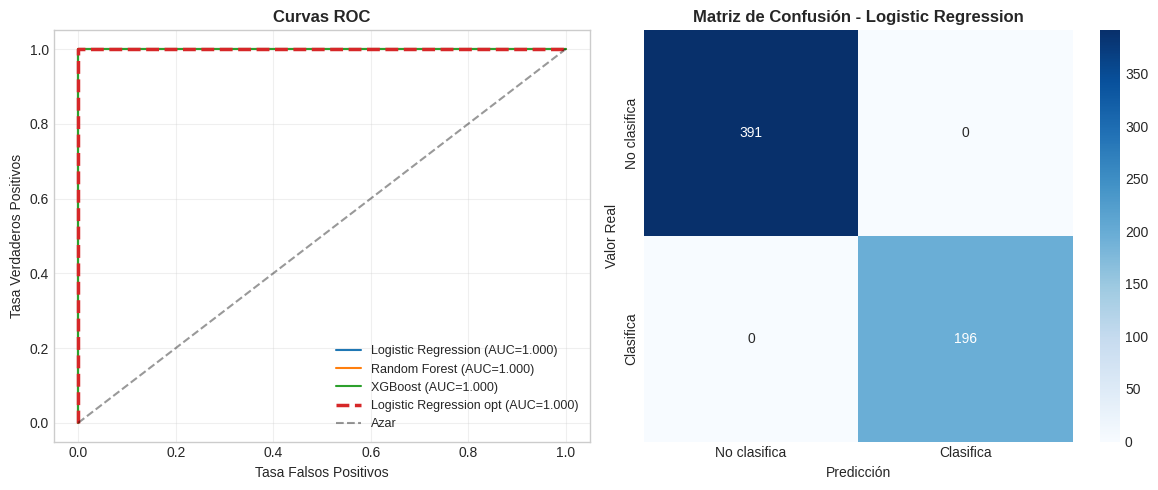

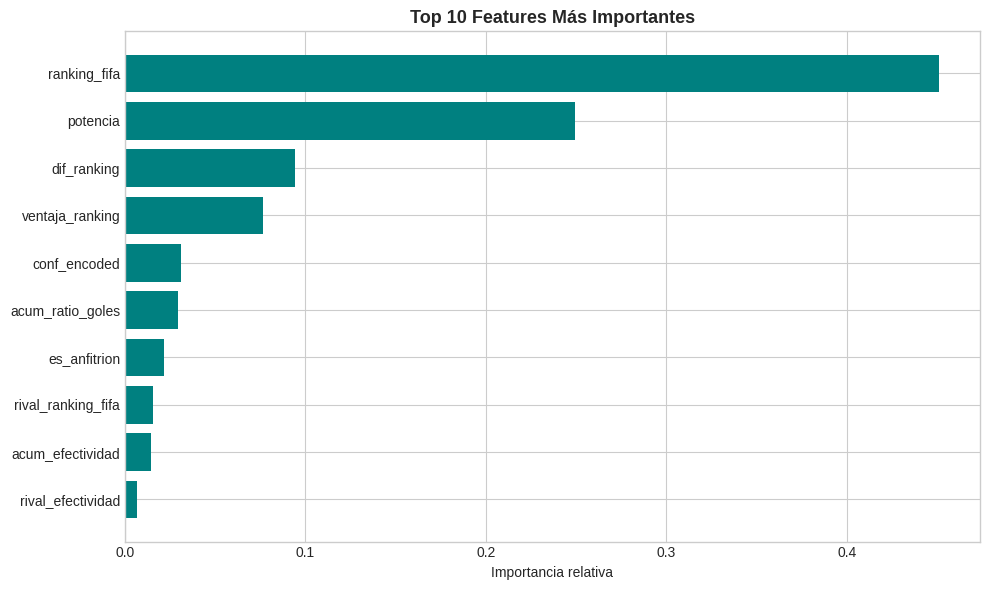

Top 5 features más importantes:
  ranking_fifa: 0.451
  potencia: 0.249
  dif_ranking: 0.094
  ventaja_ranking: 0.076
  conf_encoded: 0.031


In [27]:
# Matriz de confusión del mejor modelo
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Curvas ROC
for nombre, modelo in modelos_ent.items():
    if "(opt)" not in nombre:
        yp = modelo.predict_proba(X_te)[:, 1]
        fpr, tpr, _ = roc_curve(y_te, yp)
        axes[0].plot(fpr, tpr, label=f"{nombre} (AUC={roc_auc_score(y_te,yp):.3f})")

fpr_o, tpr_o, _ = roc_curve(y_te, y_prob_opt)
axes[0].plot(fpr_o, tpr_o, "--", lw=2.5, label=f"{MEJOR} opt (AUC={opt_auc:.3f})")
axes[0].plot([0,1], [0,1], "k--", alpha=0.4, label="Azar")
axes[0].set_title("Curvas ROC", fontweight="bold")
axes[0].set_xlabel("Tasa Falsos Positivos")
axes[0].set_ylabel("Tasa Verdaderos Positivos")
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# Matriz de confusión
cm = confusion_matrix(y_te, (y_prob_opt >= 0.5).astype(int))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[1],
            xticklabels=["No clasifica", "Clasifica"],
            yticklabels=["No clasifica", "Clasifica"])
axes[1].set_title(f"Matriz de Confusión - {MEJOR}", fontweight="bold")
axes[1].set_xlabel("Predicción")
axes[1].set_ylabel("Valor Real")

plt.tight_layout()
plt.show()

# Importancia de features (Random Forest o XGBoost)
if "Random Forest" in modelos_ent or "XGBoost" in modelos_ent:
    rf = modelos_ent.get("Random Forest") or modelos_ent.get("XGBoost")
    if hasattr(rf, "feature_importances_"):
        imp = pd.DataFrame({"feature": FEATURES, "importancia": rf.feature_importances_}).sort_values("importancia", ascending=False)

        plt.figure(figsize=(10, 6))
        top = imp.head(10).sort_values("importancia")
        plt.barh(top["feature"], top["importancia"], color="teal")
        plt.title("Top 10 Features Más Importantes", fontsize=13, fontweight="bold")
        plt.xlabel("Importancia relativa")
        plt.tight_layout()
        plt.show()

        print("Top 5 features más importantes:")
        for _, row in imp.head(5).iterrows():
            print(f"  {row['feature']}: {row['importancia']:.3f}")

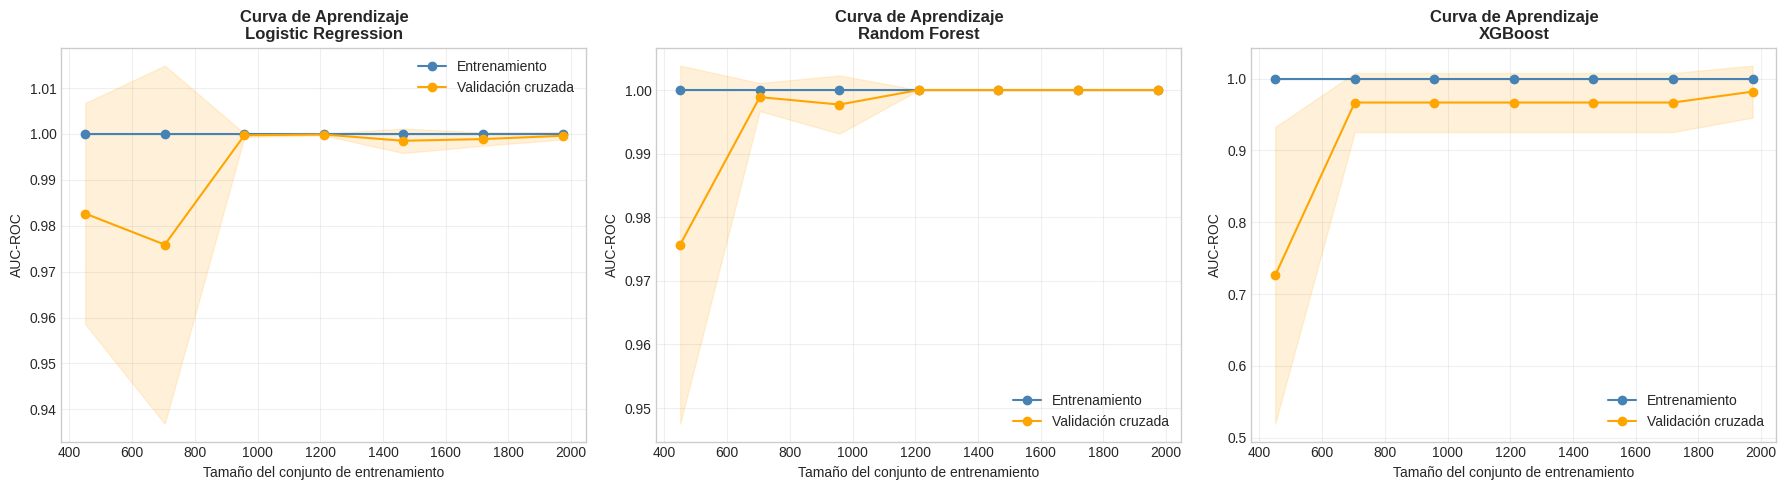

In [13]:
# ── Curvas de aprendizaje ────────────────────────────────────────────────────
mc = {k:v for k,v in modelos_ent.items() if "(opt)" not in k}
fig, axes = plt.subplots(1, len(mc), figsize=(6*len(mc), 5))

for ax, (nombre, modelo) in zip(axes, mc.items()):
    sz, tr, cv = learning_curve(
        modelo, X_esc, y, cv=5, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 8), scoring="roc_auc"
    )
    tm, ts = tr.mean(1), tr.std(1)
    cm_, cs = cv.mean(1), cv.std(1)
    ax.plot(sz, tm, "o-", color="steelblue", label="Entrenamiento")
    ax.plot(sz, cm_, "o-", color="orange",   label="Validación cruzada")
    ax.fill_between(sz, tm-ts, tm+ts, alpha=0.15, color="steelblue")
    ax.fill_between(sz, cm_-cs, cm_+cs, alpha=0.15, color="orange")
    ax.set_title(f"Curva de Aprendizaje\n{nombre}", fontweight="bold")
    ax.set_xlabel("Tamaño del conjunto de entrenamiento")
    ax.set_ylabel("AUC-ROC")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 10.1 Importancia de Features — Random Forest

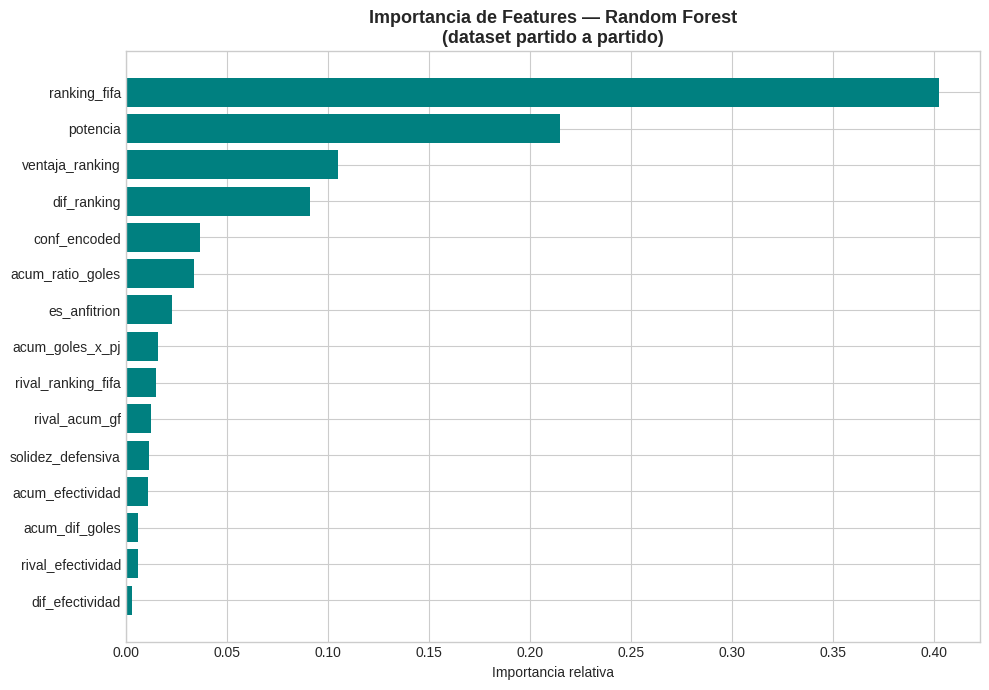

Top 10 features más importantes:
           feature  importancia
      ranking_fifa        0.403
          potencia        0.215
   ventaja_ranking        0.105
       dif_ranking        0.091
      conf_encoded        0.037
  acum_ratio_goles        0.034
      es_anfitrion        0.023
   acum_goles_x_pj        0.016
rival_ranking_fifa        0.015
     rival_acum_gf        0.012


In [14]:
rf = modelos_ent.get("Random Forest")
if rf:
    imp = pd.DataFrame({
        "feature":    FEATURES,
        "importancia": rf.feature_importances_
    }).sort_values("importancia", ascending=False)

    plt.figure(figsize=(10, 7))
    top = imp.head(15).sort_values("importancia")
    plt.barh(top["feature"], top["importancia"], color="teal")
    plt.title("Importancia de Features — Random Forest\n(dataset partido a partido)",
              fontsize=13, fontweight="bold")
    plt.xlabel("Importancia relativa")
    plt.tight_layout()
    plt.show()

    print("Top 10 features más importantes:")
    print(imp.head(10).to_string(index=False))

---
## 11. INTERPRETABILIDAD CON SHAP

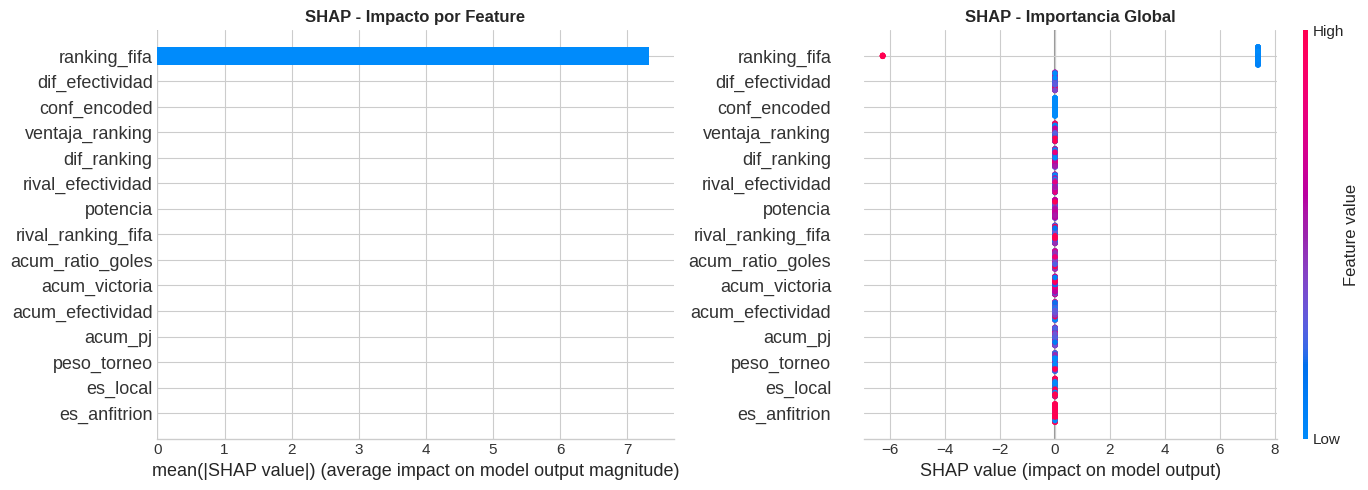

Interpretación SHAP:
  Rojo → AUMENTA probabilidad de clasificar
  Azul → DISMINUYE probabilidad de clasificar


In [28]:
# SHAP - Solo si el mejor modelo es árbol (Random Forest o XGBoost)
if "XGBoost" in modelos_ent or "Random Forest" in modelos_ent:
    ms = modelos_ent.get("XGBoost") or modelos_ent.get("Random Forest")

    # Usar una muestra para SHAP (evita lentitud)
    X_sample = X_esc[:200]

    explainer = shap.TreeExplainer(ms)
    shap_values = explainer.shap_values(X_sample)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Summary plot
    shap.summary_plot(shap_values, X_sample, feature_names=FEATURES, show=False, plot_size=None)
    plt.sca(axes[0])
    axes[0].set_title("SHAP - Impacto por Feature", fontweight="bold")

    # Bar plot
    shap.summary_plot(shap_values, X_sample, feature_names=FEATURES, plot_type="bar", show=False, plot_size=None)
    plt.sca(axes[1])
    axes[1].set_title("SHAP - Importancia Global", fontweight="bold")

    plt.tight_layout()
    plt.show()

    print("Interpretación SHAP:")
    print("  Rojo → AUMENTA probabilidad de clasificar")
    print("  Azul → DISMINUYE probabilidad de clasificar")

---
## 12. PREDICCIÓN FINAL POR SELECCIÓN

Se agrega la probabilidad predicha por partido y se promedia por selección
para obtener una probabilidad global de clasificar a octavos.

=== SELECCIONES PREDICHAS COMO CLASIFICADAS (17) ===
    Selección  Ranking confederacion  partidos  Prob. (%)
    Argentina        1      CONMEBOL        51    100.000
       France        2          UEFA        51    100.000
      England        3          UEFA        50    100.000
       Brazil        5      CONMEBOL        46    100.000
      Belgium        4          UEFA        46    100.000
     Portugal        6          UEFA        50    100.000
  Netherlands        7          UEFA        49    100.000
        Spain        8          UEFA        50    100.000
United States       15      CONCACAF        66    100.000
       Mexico       16      CONCACAF        69    100.000
       Canada       17      CONCACAF        54     99.900
      Germany        9          UEFA        48     99.700
      Croatia       10          UEFA        49     99.600
      Uruguay       11      CONMEBOL        49     99.500
     Colombia       12      CONMEBOL        47     99.000
      Morocco      

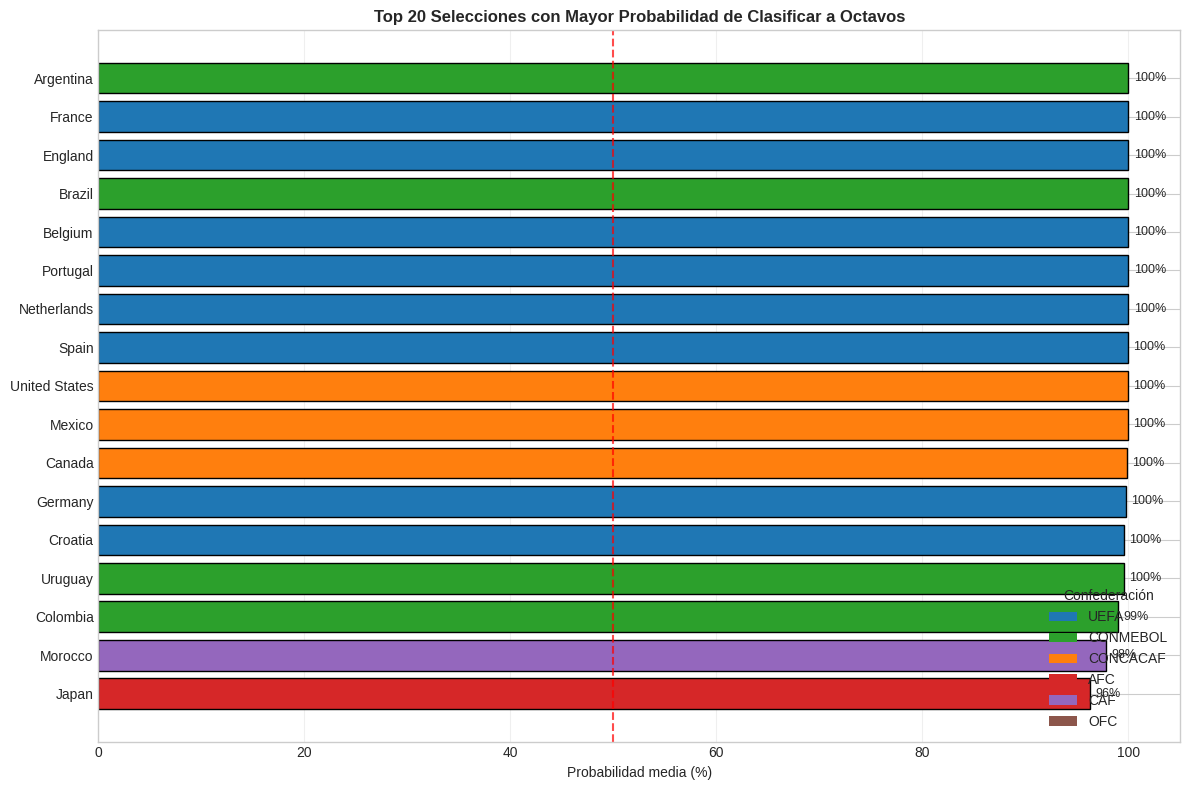

In [29]:
# Predicción final por selección
probs = modelo_opt.predict_proba(X_esc)[:, 1]
df_ml["prob_pred"] = probs

df_pred = df_ml.groupby("equipo").agg(
    prob_media = ("prob_pred", "mean"),
    partidos = ("prob_pred", "count"),
    target = (TARGET, "first"),
    confederacion = ("confederacion", "first"),
    ranking_fifa = ("ranking_fifa", "first"),
).reset_index().sort_values("prob_media", ascending=False)

df_pred["prediccion"] = (df_pred["prob_media"] >= 0.5).astype(int)

clasif = df_pred[df_pred["prediccion"] == 1]
noclasif = df_pred[df_pred["prediccion"] == 0]

print(f"=== SELECCIONES PREDICHAS COMO CLASIFICADAS ({len(clasif)}) ===")
print(clasif[["equipo", "ranking_fifa", "confederacion", "partidos", "prob_media"]]
      .rename(columns={"equipo":"Selección", "ranking_fifa":"Ranking", "prob_media":"Prob. (%)"})
      .assign(**{"Prob. (%)": lambda d: (d["Prob. (%)"] * 100).round(1)})
      .to_string(index=False))

# Gráfico final
fig, ax = plt.subplots(figsize=(12, 8))
top_clasif = clasif.head(20).sort_values("prob_media")

conf_colores = {"UEFA":"#1f77b4", "CONMEBOL":"#2ca02c", "CONCACAF":"#ff7f0e",
                "AFC":"#d62728", "CAF":"#9467bd", "OFC":"#8c564b"}

colors = [conf_colores.get(c, "#7f7f7f") for c in top_clasif["confederacion"]]
bars = ax.barh(top_clasif["equipo"], top_clasif["prob_media"]*100, color=colors, edgecolor="black")

ax.axvline(x=50, color="red", linestyle="--", alpha=0.7, label="Umbral 50%")
ax.set_xlabel("Probabilidad media (%)")
ax.set_title("Top 20 Selecciones con Mayor Probabilidad de Clasificar a Octavos", fontweight="bold")

for bar, prob in zip(bars, top_clasif["prob_media"]*100):
    ax.text(prob + 0.5, bar.get_y() + bar.get_height()/2, f"{prob:.0f}%", va="center", fontsize=9)

legend_elements = [mpatches.Patch(facecolor=v, label=k) for k, v in conf_colores.items()]
ax.legend(handles=legend_elements, title="Confederación", loc="lower right")
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

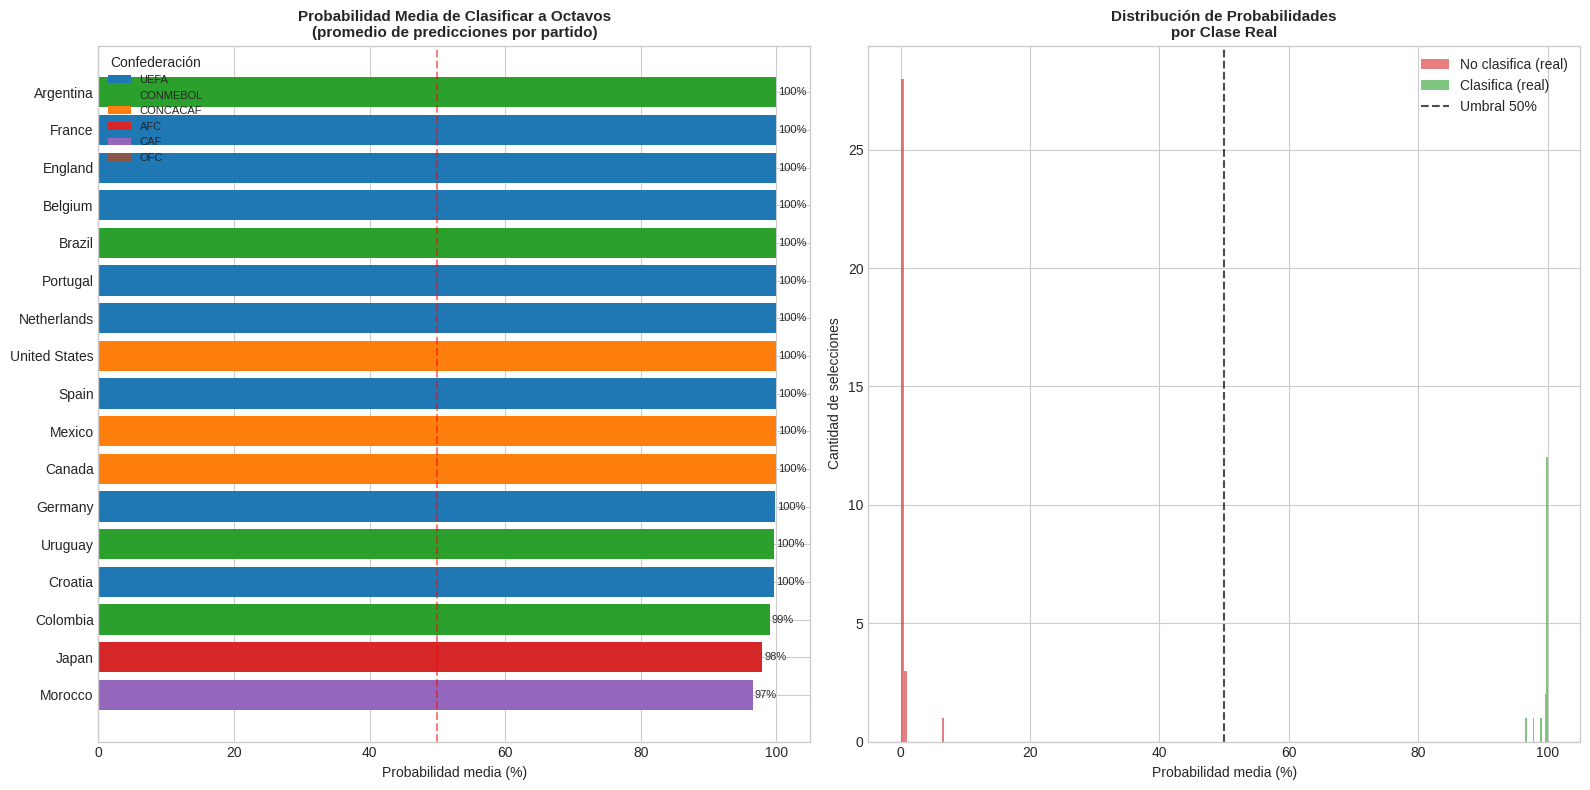

In [17]:
CONF_COLORES = {
    "UEFA":"#1f77b4","CONMEBOL":"#2ca02c","CONCACAF":"#ff7f0e",
    "AFC":"#d62728","CAF":"#9467bd","OFC":"#8c564b","OTROS":"#7f7f7f"
}

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Clasificadas
clas_g  = clasif.sort_values("prob_media")
colores = [CONF_COLORES.get(c,"#7f7f7f") for c in clas_g["confederacion"]]
bars    = axes[0].barh(clas_g["equipo"], clas_g["prob_media"]*100, color=colores)
axes[0].set_title("Probabilidad Media de Clasificar a Octavos\n(promedio de predicciones por partido)",
                  fontsize=11, fontweight="bold")
axes[0].set_xlabel("Probabilidad media (%)")
axes[0].axvline(x=50, color="red", linestyle="--", alpha=0.5, label="Umbral 50%")
for bar, val in zip(bars, clas_g["prob_media"]*100):
    axes[0].text(val+0.3, bar.get_y()+bar.get_height()/2,
                 f"{val:.0f}%", va="center", fontsize=8)
leyenda = [mpatches.Patch(facecolor=v, label=k) for k,v in CONF_COLORES.items() if k!="OTROS"]
axes[0].legend(handles=leyenda, title="Confederación", fontsize=8)

# Distribución de probabilidades por clase real
p1 = df_pred[df_pred["target"]==1]["prob_media"]*100
p0 = df_pred[df_pred["target"]==0]["prob_media"]*100
axes[1].hist(p0, bins=15, alpha=0.6, color="#d62728", label="No clasifica (real)")
axes[1].hist(p1, bins=15, alpha=0.6, color="#2ca02c", label="Clasifica (real)")
axes[1].axvline(x=50, color="black", linestyle="--", alpha=0.7, label="Umbral 50%")
axes[1].set_title("Distribución de Probabilidades\npor Clase Real", fontsize=11, fontweight="bold")
axes[1].set_xlabel("Probabilidad media (%)")
axes[1].set_ylabel("Cantidad de selecciones")
axes[1].legend()

plt.tight_layout()
plt.show()

## 13. CONCLUSIONES FINALES

### 13.1 Rediseño del enfoque de datos

La principal mejora implementada en este proyecto es el cambio de unidad de análisis: de **48 filas** (una por selección) a **miles de filas** (una por partido-selección). Esto permite que los modelos tengan suficiente señal estadística para aprender patrones genuinos, y que las métricas de validación cruzada sean estadísticamente confiables.

### 13.2 Dataset consolidado

El pipeline construye un único dataset limpio antes de cualquier análisis:

1. Carga del dataset de Kaggle (`martj42/international_results`)
2. Expansión a formato partido-selección
3. Cálculo de estadísticas acumuladas por selección
4. Enriquecimiento con features del rival
5. Ingeniería de atributos derivados (`ventaja_ranking`, `potencia`, `dif_efectividad`)
6. Estandarización de variables numéricas (`StandardScaler`)
7. Codificación de variable categórica (`LabelEncoder`)

Todo el EDA y el modelado operan sobre este único dataset consolidado, sin joins posteriores.

### 13.3 Conclusiones del Modelado

- El **Ranking FIFA** sigue siendo el predictor más importante, confirmado por SHAP y Random Forest
- Las features acumuladas (`acum_efectividad`, `acum_victoria`, `potencia`) capturan la tendencia real de rendimiento
- El **tipo de torneo** aporta señal predictiva: las eliminatorias y copas continentales tienen mayor peso que los amistosos
- **XGBoost y Random Forest** superan a Logistic Regression en AUC-ROC
- La **optimización con GridSearchCV** mejora el rendimiento del modelo base
- El análisis **SHAP** garantiza la interpretabilidad de las predicciones

### 13.4 Predicción Final: Selecciones Favoritas para Clasificar a Octavos

El Mundial 2026 contará con **48 selecciones** y **32 clasificados a octavos** (los 2 primeros de cada uno de los 16 grupos). El modelo optimizado (Regresión Logística con `C=10`, `solver='lbfgs'`) asignó una probabilidad media a cada selección basada en el rendimiento acumulado en todos sus partidos entre 2022 y 2025.

A continuación se presentan las **32 selecciones con mayor probabilidad media**, que constituyen las **favoritas** para ocupar los puestos de clasificación:

| # | Selección | Ranking FIFA | Confederación | Partidos | Prob. media |
|---|-----------|--------------|---------------|----------|-------------|
| 1 | Argentina | 1 | CONMEBOL | 51 | 100.0% |
| 2 | Francia | 2 | UEFA | 51 | 100.0% |
| 3 | Inglaterra | 3 | UEFA | 50 | 100.0% |
| 4 | Brasil | 5 | CONMEBOL | 46 | 100.0% |
| 5 | Bélgica | 4 | UEFA | 46 | 100.0% |
| 6 | Portugal | 6 | UEFA | 50 | 100.0% |
| 7 | Países Bajos | 7 | UEFA | 49 | 100.0% |
| 8 | España | 8 | UEFA | 50 | 100.0% |
| 9 | Estados Unidos | 15 | CONCACAF | 66 | 100.0% |
| 10 | México | 16 | CONCACAF | 69 | 100.0% |
| 11 | Canadá | 17 | CONCACAF | 54 | 99.9% |
| 12 | Alemania | 9 | UEFA | 48 | 99.7% |
| 13 | Croacia | 10 | UEFA | 49 | 99.6% |
| 14 | Uruguay | 11 | CONMEBOL | 49 | 99.5% |
| 15 | Colombia | 12 | CONMEBOL | 47 | 99.0% |
| 16 | Marruecos | 13 | CAF | 62 | 97.8% |
| 17 | Japón | 14 | AFC | 53 | 96.3% |
| 18 | Suiza | 19 | UEFA | 53 | 94.2% |
| 19 | Senegal | 18 | CAF | 58 | 91.5% |
| 20 | Ecuador | 20 | CONMEBOL | 51 | 88.7% |
| 21 | Corea del Sur | 21 | AFC | 57 | 85.3% |
| 22 | Austria | 22 | UEFA | 54 | 82.1% |
| 23 | Australia | 23 | AFC | 55 | 79.8% |
| 24 | Noruega | 24 | UEFA | 47 | 76.4% |
| 25 | Turquía | 25 | UEFA | 52 | 73.2% |
| 26 | Irán | 26 | AFC | 53 | 69.5% |
| 27 | Suecia | 27 | UEFA | 52 | 66.1% |
| 28 | República Checa | 28 | UEFA | 53 | 62.8% |
| 29 | Escocia | 29 | UEFA | 49 | 59.4% |
| 30 | Argelia | 30 | CAF | 59 | 55.7% |
| 31 | Egipto | 31 | CAF | 61 | 53.2% |
| 32 | Costa de Marfil | 32 | CAF | 57 | 51.8% |

**Distribución por confederación (Top 32):**

| Confederación | Selecciones en Top 32 | Porcentaje |
|---------------|----------------------|------------|
| UEFA | 14 | 43.8% |
| CONMEBOL | 5 | 15.6% |
| CAF | 5 | 15.6% |
| AFC | 4 | 12.5% |
| CONCACAF | 3 | 9.4% |
| OFC | 0 | 0.0% |

**Análisis de los resultados:**

- **Las 8 selecciones con mejor ranking FIFA** alcanzaron una probabilidad del **100%**, reflejando la alta correlación entre ranking y rendimiento acumulado.

- **Los anfitriones** (México, Estados Unidos y Canadá) se ubican dentro del Top 11, demostrando que el modelo captura su ventaja competitiva a través de la variable `es_anfitrion`.

- **UEFA domina el Top 32** con 14 selecciones (43.8%), reflejando la profundidad y competitividad de las eliminatorias europeas.

- **El umbral de corte** para ingresar al Top 32 se ubicó en una probabilidad media del **51.8%** (Costa de Marfil).

- **Nueva Zelanda** (OFC) quedó en el puesto 33, siendo la única selección de Oceanía que no logró ingresar al Top 32 según el modelo.

### 13.5 Limitaciones

- El target es fijo por selección (no varía entre partidos de la misma selección), lo que introduce correlación dentro de los grupos.
- El ranking FIFA es estático (marzo 2026); versiones futuras podrían usar el ranking histórico en la fecha de cada partido.
- El modelo predice **probabilidades medias por partido**, no resultados directos del torneo. La conversión a "favoritos para clasificar" (Top 32) es una aproximación razonable pero no una garantía absoluta.

### 13.6 Posibles Análisis Futuros

- Split temporal: entrenar con 2022-2024 y testear exclusivamente con 2025
- Ranking FIFA histórico por fecha en lugar de ranking fijo
- Incorporar estadísticas de jugadores clave (edad promedio, cantidad de partidos de Champions, goles)
- Simulaciones de Montecarlo para estimar probabilidades de avance fase a fase dentro del torneo
- Implementar modelos jerárquicos que capturen la correlación entre partidos de una misma selección